In [ ]:
# Поиск стран
# Напишите программу, которая:
# Парсит таблицу с сайта https://www.iban.com/country-codes и сохраняет ее в подходящей структуре данных;
# Запрашивает у пользователя код страны (пользователь может ввести двухбуквенный или трехбуквенный код) и выводит название страны, 
# соответствующей этому коду.



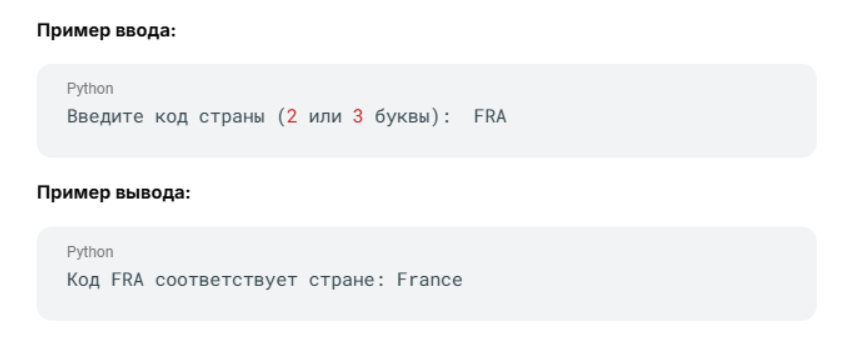


In [54]:
import requests
import json
import os
from bs4 import BeautifulSoup
url = 'https://www.iban.com/country-codes'
response = requests.get(url)
if response.status_code == 200:
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table')
    headers = [th.text.strip() for th in table.find_all("th")]
    # print(headers)
    # print("-"*100)
    data = []
    rows = table.find_all("tr")[1:] 
    for row in rows:
        cols = [td.text.strip() for td in row.find_all("td")]
        # print(cols)
        row_dict = dict(zip(headers, cols))
        data.append(row_dict)
    # for row_data in data:
    #     print(row_data)
else:
    print('Ошибка при запросе:', response.status_code)
try:    
    with open("country.json", "w", encoding="utf-8") as f:
        write = json.dump(data, f, indent=4, ensure_ascii=False)
        if os.path.exists("country.json"):
            print(f"Файл {"country.json"} создан. Размер: {os.path.getsize("country.json")} байт.")
            print("-"*100)
        else:
            print("Что-то пошло не так: файл не найден после записи.") 
except Exception as e:
    print(f"Ошибка при записи файла: {e}")  

code_country = input("Введите код страны (2 или 3 латниские буквы): ")
if len(code_country) == 2:
    for item in data:
        if item["Alpha-2 code"] == code_country.upper():
            print(f"Код {code_country} соответствует стране: {item['Country']}")
            break
    else:
        print(f"Код {code_country} не найден в таблице")
        
elif len(code_country) == 3:
    for item in data:
        if item["Alpha-3 code"] == code_country.upper():
            print(f"Код {code_country} соответствует стране: {item['Country']}")
            break
    else:
        print(f"Код {code_country} не найден в таблице")
        
else: 
    print("Вы указали неверный код страны.")

Файл country.json создан. Размер: 32783 байт.
----------------------------------------------------------------------------------------------------


Введите код страны (2 или 3 латниские буквы):  PAK


Код PAK соответствует стране: Pakistan
